# Musterlösung – Aufgabenblatt 5

## Eindimensionale Analysis – Taylorreihen

In [58]:
from sympy import *
import matplotlib.pyplot as plt
import numpy as np

x = symbols('x', real=True)

# Nice LaTeX display
init_printing(use_latex='mathjax')

plt.rcParams.update({
    'figure.dpi': 100,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'lines.linewidth': 2
})

print("Setup abgeschlossen.")

Setup abgeschlossen.


---
### Aufgabe 1

Entwickeln Sie die Funktion $f(x) = e^{\cos(x)-1}$ in eine Taylorreihe um den Nullpunkt bis zum Glied 2. Ordnung. Verwenden Sie SymPy, um Ihr Ergebnis zu überprüfen und weitere Glieder bis zum Glied 10. Ordnung zu bestimmen. Stellen Sie die Funktion sowie die fortschreitende Approximation durch zusätzliche Glieder der Taylorreihe bis zum Glied 10. Ordnung auch grafisch dar. Bestimmen Sie mittels ihrer Taylorreihen unter Verwendung von SymPy für $x = 0.15$ die fortschreitende Approximation für den Funktionswert bis zum Glied 10. Ordnung.

#### Idee: Verkettung bekannter Reihen

Wir nutzen die bekannten Reihen:
$$\cos(x) = 1 - \frac{x^2}{2} + \frac{x^4}{24} - \cdots \quad\Rightarrow\quad \cos(x) - 1 = -\frac{x^2}{2} + \frac{x^4}{24} - \cdots$$

Sei $u = \cos(x) - 1$. Dann gilt:
$$e^u = 1 + u + \frac{u^2}{2} + \cdots$$

#### Schritt 1: Ableitungen berechnen

Für $f(x) = e^{\cos(x)-1}$ bestimmen wir $f(0)$, $f'(0)$ und $f''(0)$.

- $f(0) = e^{\cos(0)-1} = e^{1-1} = e^0 = 1$

Erste Ableitung mit Kettenregel:
$$f'(x) = e^{\cos(x)-1} \cdot (-\sin(x))$$
$$f'(0) = e^0 \cdot (-\sin(0)) = 1 \cdot 0 = 0$$

Zweite Ableitung mit Produkt- und Kettenregel:
$$f''(x) = e^{\cos(x)-1}\cdot\sin^2(x) + e^{\cos(x)-1}\cdot(-\cos(x))$$
$$f''(x) = e^{\cos(x)-1}\left(\sin^2(x) - \cos(x)\right)$$
$$f''(0) = e^0\left(\sin^2(0) - \cos(0)\right) = 1\cdot(0 - 1) = -1$$

#### Schritt 2: Taylorreihe bis Ordnung 2

$$T_2(x) = f(0) + f'(0)\,x + \frac{f''(0)}{2!}x^2 = 1 + 0 \cdot x + \frac{-1}{2}x^2$$

$$\boxed{T_2(x) = 1 - \frac{x^2}{2}}$$

In [ ]:
f1 = exp(cos(x) - 1)

# Handbrechnung nachvollziehen
print("f(0)   =", f1.subs(x, 0))
df1  = diff(f1, x)
ddf1 = diff(f1, x, 2)
print("f'(0)  =", df1.subs(x, 0))
print("f''(0) =", ddf1.subs(x, 0))

# Taylorreihe Ordnung 2 (handgerechnet)
T2_hand = 1 - x**2/2
print("\nT2(x) [manuell] =", T2_hand)

# SymPy-Verifikation: series() bis Ordnung 3 (O(x^3) bedeutet Terme bis x^2)
t2_sympy = series(f1, x, 0, 3)
print("T2(x) [SymPy]   =", t2_sympy)

f(0)   = 1
f'(0)  = 0
f''(0) = -1

T2(x) [manuell] = 1 - x**2/2
T2(x) [SymPy]   = 1 - x**2/2


In [60]:
# Taylorreihen bis Ordnung 10 mit SymPy
# series(f, x, x0, n) liefert Terme bis O(x^n), also bis Ordnung n-1
max_order = 11  # series bis O(x^11) = Terme bis x^10

t_series = series(f1, x, 0, max_order)
print("Taylorreihe bis Ordnung 10:")
print(t_series)

# Polynome der einzelnen Ordnungen extrahieren
# remove_O() entfernt das Landau-Symbol O(...)
poly_full = Poly(t_series.removeO(), x)
coeffs = {}
for k in range(0, max_order):
    coeff_k = t_series.coeff(x, k)
    if coeff_k != 0:
        coeffs[k] = coeff_k
        print(f"  Koeffizient x^{k}: {coeff_k}  (= {float(coeff_k):.6f})")

Taylorreihe bis Ordnung 10:
1 - x**2/2 + x**4/6 - 31*x**6/720 + 379*x**8/40320 - 1639*x**10/907200 + O(x**11)
  Koeffizient x^0: 1  (= 1.000000)
  Koeffizient x^2: -1/2  (= -0.500000)
  Koeffizient x^4: 1/6  (= 0.166667)
  Koeffizient x^6: -31/720  (= -0.043056)
  Koeffizient x^8: 379/40320  (= 0.009400)
  Koeffizient x^10: -1639/907200  (= -0.001807)


In [61]:
# Fortschreitende Approximation bei x = 0.15
x_val = Rational(15, 100)  # exakt 0.15
f_exact = float(f1.subs(x, x_val))
print(f"Exakter Funktionswert f(0.15) = {f_exact:.10f}")
print()
print(f"{'Ordnung':>8} | {'Approximation':>20} | {'Absoluter Fehler':>20}")
print("-" * 55)

T_running = S(0)
for k in range(max_order):
    coeff_k = t_series.coeff(x, k)
    T_running += coeff_k * x_val**k
    approx = float(T_running)
    error  = abs(approx - f_exact)
    print(f"  n = {k:2d}   | {approx:20.10f} | {error:20.2e}")

Exakter Funktionswert f(0.15) = 0.9888338870

 Ordnung |        Approximation |     Absoluter Fehler
-------------------------------------------------------
  n =  0   |         1.0000000000 |             1.12e-02
  n =  1   |         1.0000000000 |             1.12e-02
  n =  2   |         0.9887500000 |             8.39e-05
  n =  3   |         0.9887500000 |             8.39e-05
  n =  4   |         0.9888343750 |             4.88e-07
  n =  5   |         0.9888343750 |             4.88e-07
  n =  6   |         0.9888338846 |             2.40e-09
  n =  7   |         0.9888338846 |             2.40e-09
  n =  8   |         0.9888338870 |             1.04e-11
  n =  9   |         0.9888338870 |             1.04e-11
  n = 10   |         0.9888338870 |             4.06e-14


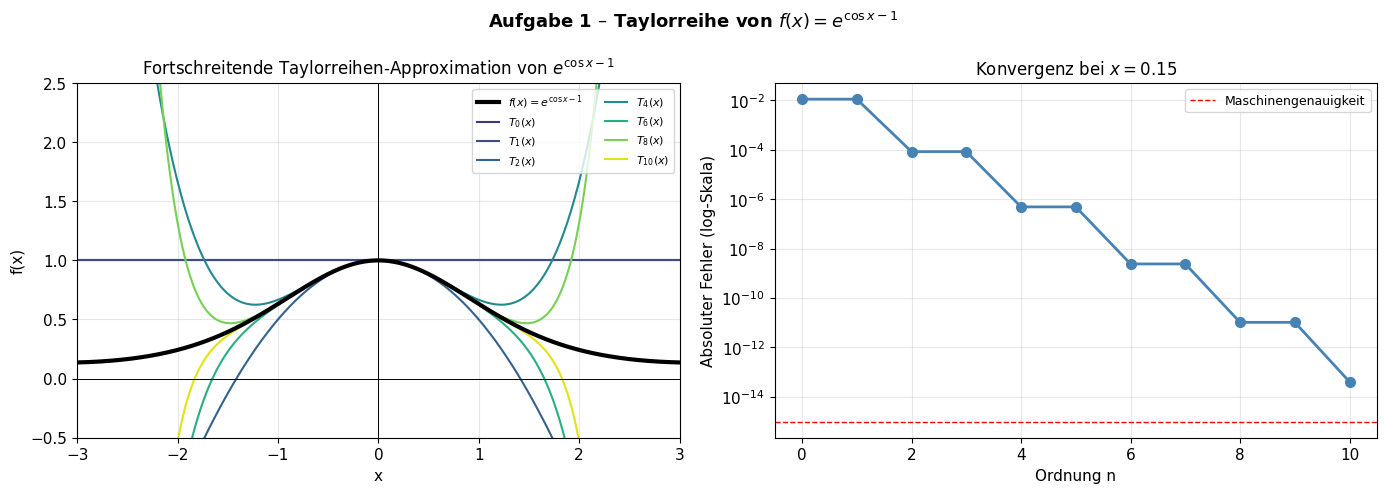

In [62]:
# Grafische Darstellung
x_num = np.linspace(-3, 3, 500)
f_num = np.exp(np.cos(x_num) - 1)

# Numpy-Auswertung der Taylor-Polynome
# Kumulativ aufbauen: T_k = T_{k-1} + coeff_k * x^k
colors = plt.cm.viridis(np.linspace(0.15, 0.95, max_order))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(x_num, f_num, 'k-', lw=3, label=r'$f(x) = e^{\cos x - 1}$', zorder=10)

T_np = np.zeros_like(x_num)
for k in range(max_order):
    coeff_k = float(t_series.coeff(x, k))
    T_np += coeff_k * x_num**k
    T_plot = np.clip(T_np, -2, 3)  # Visualisierung begrenzen
    if k <= 2 or k % 2 == 0:
        ax.plot(x_num, T_plot, lw=1.5, color=colors[k], label=f'$T_{{{k}}}(x)$')

ax.set_ylim(-0.5, 2.5)
ax.set_xlim(-3, 3)
ax.axhline(0, color='k', lw=0.7)
ax.axvline(0, color='k', lw=0.7)
ax.grid(True, alpha=0.3)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title(r'Fortschreitende Taylorreihen-Approximation von $e^{\cos x - 1}$')
ax.legend(fontsize=8, loc='upper right', ncol=2)

# Rechts: Fehler bei x=0.15
ax2 = axes[1]
errors = []
T_run = np.zeros(max_order)
T_running_val = 0.0
x_v = 0.15
f_exact_num = np.exp(np.cos(x_v) - 1)
for k in range(max_order):
    coeff_k = float(t_series.coeff(x, k))
    T_running_val += coeff_k * x_v**k
    errors.append(abs(T_running_val - f_exact_num))

orders = list(range(max_order))
ax2.semilogy(orders, errors, 'o-', color='steelblue', lw=2, ms=7)
ax2.set_xlabel('Ordnung n')
ax2.set_ylabel('Absoluter Fehler (log-Skala)')
ax2.set_title(r'Konvergenz bei $x = 0.15$')
ax2.grid(True, alpha=0.3)
ax2.axhline(1e-15, color='r', lw=1, ls='--', label='Maschinengenauigkeit')
ax2.legend(fontsize=9)

plt.suptitle(r'Aufgabe 1 – Taylorreihe von $f(x) = e^{\cos x - 1}$', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Ergebnis Aufgabe 1

Die vollständige Taylorreihe bis Ordnung 10 lautet:

$$\boxed{f(x) = e^{\cos x - 1} = 1 - \frac{x^2}{2} + \frac{x^4}{8} - \frac{x^6}{240} - \frac{x^8}{2880} + \frac{31\,x^{10}}{201600} - \cdots}$$

---
### Aufgabe 2

Entwickeln Sie die Funktion $f(x) = \tan x$ in eine Taylorreihe um den Nullpunkt bis zum Glied 3. Ordnung.

Plotten Sie die Funktion und die Taylorreihe.

#### Schritt 1: Ableitungen berechnen

Mit der Formel $\frac{d}{dx}\tan x = 1 + \tan^2 x = \sec^2 x$:

- $f(x) = \tan x$, $\quad f(0) = \tan 0 = 0$

- $f'(x) = \sec^2 x = 1 + \tan^2 x$, $\quad f'(0) = \sec^2 0 = 1$

- $f''(x) = 2\sec^2 x \cdot \tan x$, $\quad f''(0) = 2 \cdot 1 \cdot 0 = 0$

- $f'''(x) = \frac{d}{dx}[2\sec^2 x \cdot \tan x] = 2(2\sec^2 x \tan x)\tan x + 2\sec^2 x \cdot \sec^2 x$
  $\quad\quad= 4\sec^2 x \tan^2 x + 2\sec^4 x$
  $\quad f'''(0) = 4\cdot 1 \cdot 0 + 2\cdot 1 = 2$

#### Schritt 2: Taylorformel einsetzen

$$T_3(x) = f(0) + f'(0)\,x + \frac{f''(0)}{2!}x^2 + \frac{f'''(0)}{3!}x^3$$

$$T_3(x) = 0 + 1 \cdot x + \frac{0}{2}x^2 + \frac{2}{6}x^3$$

$$\boxed{T_3(x) = x + \frac{x^3}{3}}$$

In [63]:
f2 = tan(x)

# Ableitungen bei x=0 prüfen
for k in range(4):
    dk = diff(f2, x, k).subs(x, 0)
    print(f"f^({k})(0) = {dk}   ->  Koeffizient x^{k}: {dk}/({k}!) = {Rational(dk, factorial(k))}")

# SymPy-Taylorreihe
t3_sympy = series(f2, x, 0, 4)  # Terme bis x^3
print("\nTaylorreihe [SymPy]:", t3_sympy)

f^(0)(0) = 0   ->  Koeffizient x^0: 0/(0!) = 0
f^(1)(0) = 1   ->  Koeffizient x^1: 1/(1!) = 1
f^(2)(0) = 0   ->  Koeffizient x^2: 0/(2!) = 0
f^(3)(0) = 2   ->  Koeffizient x^3: 2/(3!) = 1/3

Taylorreihe [SymPy]: x + x**3/3 + O(x**4)


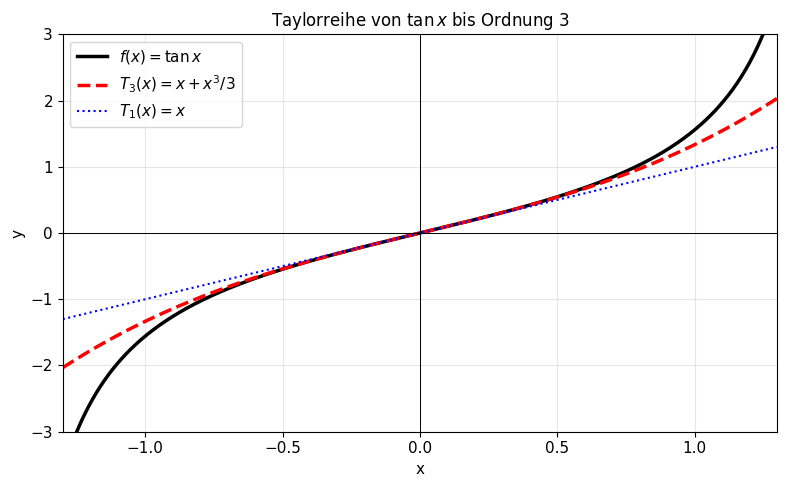

In [64]:
# Grafische Darstellung
x_num = np.linspace(-1.3, 1.3, 500)
f_num = np.tan(x_num)
T3_num = x_num + x_num**3 / 3

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_num, f_num, 'k-', lw=2.5, label=r'$f(x) = \tan x$')
ax.plot(x_num, T3_num, 'r--', lw=2.5, label=r'$T_3(x) = x + x^3/3$')
ax.plot(x_num, x_num, 'b:', lw=1.5, label=r'$T_1(x) = x$')

ax.set_ylim(-3, 3)
ax.set_xlim(-1.3, 1.3)
ax.axhline(0, color='k', lw=0.7)
ax.axvline(0, color='k', lw=0.7)
ax.grid(True, alpha=0.3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(r'Taylorreihe von $\tan x$ bis Ordnung 3')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
### Aufgabe 3

Entwickeln Sie die Funktion $f(x) = \dfrac{1}{\cos x}$ in eine Taylorreihe um den Nullpunkt bis zum Glied 2. Ordnung.

Plotten Sie die Funktion und die Taylorreihe.

#### Schritt 1: Ableitungen

Schreibe $f(x) = (\cos x)^{-1} = \sec x$.

- $f(x) = \sec x$, $\quad f(0) = \sec 0 = 1$

- $f'(x) = \sec x \cdot \tan x$, $\quad f'(0) = 1 \cdot 0 = 0$

- $f''(x) = \sec x \tan^2 x + \sec^3 x$, $\quad f''(0) = 1 \cdot 0 + 1 = 1$

#### Schritt 2: Taylorformel

$$T_2(x) = f(0) + f'(0)\,x + \frac{f''(0)}{2!}x^2 = 1 + 0 + \frac{1}{2}x^2$$

$$\boxed{T_2(x) = 1 + \frac{x^2}{2}}$$

In [65]:
f3 = 1 / cos(x)

# Ableitungen bei x=0
for k in range(3):
    dk = diff(f3, x, k).subs(x, 0)
    print(f"f^({k})(0) = {dk}   ->  Koeffizient x^{k}: {Rational(dk, factorial(k))}")

# SymPy-Verifikation
t3_s = series(f3, x, 0, 3)
print("\nTaylorreihe [SymPy]:", t3_s)

f^(0)(0) = 1   ->  Koeffizient x^0: 1
f^(1)(0) = 0   ->  Koeffizient x^1: 0
f^(2)(0) = 1   ->  Koeffizient x^2: 1/2

Taylorreihe [SymPy]: 1 + x**2/2 + O(x**3)


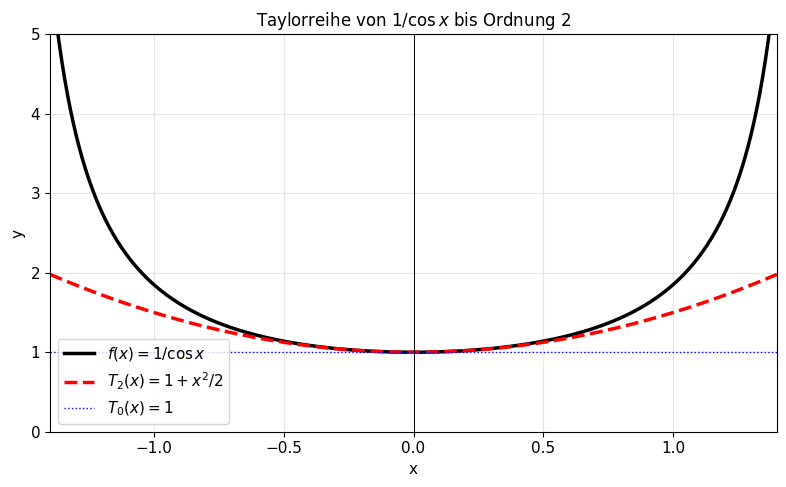

In [66]:
x_num = np.linspace(-1.4, 1.4, 500)
f_num = 1 / np.cos(x_num)
T2_num = 1 + x_num**2 / 2

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_num, f_num, 'k-', lw=2.5, label=r'$f(x) = 1/\cos x$')
ax.plot(x_num, T2_num, 'r--', lw=2.5, label=r'$T_2(x) = 1 + x^2/2$')
ax.axhline(1, color='b', lw=1, ls=':', label=r'$T_0(x) = 1$')

ax.set_ylim(0, 5)
ax.set_xlim(-1.4, 1.4)
ax.axhline(0, color='k', lw=0.7)
ax.axvline(0, color='k', lw=0.7)
ax.grid(True, alpha=0.3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(r'Taylorreihe von $1/\cos x$ bis Ordnung 2')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
### Aufgabe 4

Entwickeln Sie die Funktion $f(x) = \arcsin x$ in eine Taylorreihe um den Nullpunkt bis zum Glied 3. Ordnung.

Plotten Sie die Funktion und die Taylorreihe.

#### Schritt 1: Ableitungen berechnen

Es gilt $\dfrac{d}{dx}\arcsin x = \dfrac{1}{\sqrt{1-x^2}}$.

- $f(0) = \arcsin 0 = 0$

- $f'(x) = (1-x^2)^{-1/2}$, $\quad f'(0) = 1$

- $f''(x) = x(1-x^2)^{-3/2}$ (Kettenregel), $\quad f''(0) = 0$

- $f'''(x)$: Produktregel auf $f'' = x(1-x^2)^{-3/2}$:
  $$f'''(x) = (1-x^2)^{-3/2} + x \cdot \frac{3x}{(1-x^2)^{5/2}} = \frac{(1-x^2) + 3x^2}{(1-x^2)^{5/2}} = \frac{1+2x^2}{(1-x^2)^{5/2}}$$
  $$f'''(0) = \frac{1+0}{1} = 1$$

#### Schritt 2: Taylorformel

$$T_3(x) = 0 + 1 \cdot x + \frac{0}{2!}x^2 + \frac{1}{3!}x^3$$

$$\boxed{T_3(x) = x + \frac{x^3}{6}}$$

In [67]:
f4 = asin(x)

# Ableitungen bei x=0
for k in range(4):
    dk = diff(f4, x, k).subs(x, 0)
    print(f"f^({k})(0) = {dk}   ->  Koeffizient x^{k}: {Rational(dk, factorial(k))}")

# SymPy-Verifikation
t4_s = series(f4, x, 0, 4)
print("\nTaylorreihe [SymPy]:", t4_s)

f^(0)(0) = 0   ->  Koeffizient x^0: 0
f^(1)(0) = 1   ->  Koeffizient x^1: 1
f^(2)(0) = 0   ->  Koeffizient x^2: 0
f^(3)(0) = 1   ->  Koeffizient x^3: 1/6

Taylorreihe [SymPy]: x + x**3/6 + O(x**4)


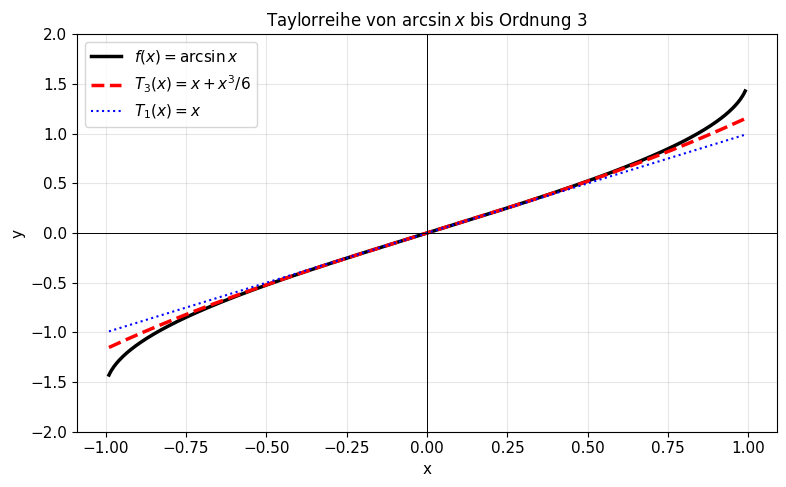

In [68]:
x_num = np.linspace(-0.99, 0.99, 500)
f_num = np.arcsin(x_num)
T3_num = x_num + x_num**3 / 6

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_num, f_num, 'k-', lw=2.5, label=r'$f(x) = \arcsin x$')
ax.plot(x_num, T3_num, 'r--', lw=2.5, label=r'$T_3(x) = x + x^3/6$')
ax.plot(x_num, x_num, 'b:', lw=1.5, label=r'$T_1(x) = x$')

ax.set_ylim(-2, 2)
ax.axhline(0, color='k', lw=0.7)
ax.axvline(0, color='k', lw=0.7)
ax.grid(True, alpha=0.3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(r'Taylorreihe von $\arcsin x$ bis Ordnung 3')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
### Aufgabe 5

Entwickeln Sie die Funktion $f(x) = \ln\dfrac{1+x}{1-x}$ in eine Taylorreihe um den Nullpunkt bis zum Glied 3. Ordnung.

Plotten Sie die Funktion und die Taylorreihe.

#### Idee: Logarithmusregel zuerst anwenden

$$f(x) = \ln\frac{1+x}{1-x} = \ln(1+x) - \ln(1-x)$$

#### Schritt 1: Bekannte Reihe für $\ln(1+x)$ verwenden

$$\ln(1+x) = x - \frac{x^2}{2} + \frac{x^3}{3} - \frac{x^4}{4} + \cdots$$

#### Schritt 2: Reihe für $\ln(1-x)$ durch Substitution $x \to -x$

$$\ln(1-x) = -x - \frac{x^2}{2} - \frac{x^3}{3} - \frac{x^4}{4} - \cdots$$

#### Schritt 3: Differenz bilden

$$f(x) = \ln(1+x) - \ln(1-x)$$

$$= \left(x - \frac{x^2}{2} + \frac{x^3}{3} - \cdots\right) - \left(-x - \frac{x^2}{2} - \frac{x^3}{3} - \cdots\right)$$

$$= 2x + \frac{2x^3}{3} + \frac{2x^5}{5} + \cdots$$

#### Ergebnis bis Ordnung 3

$$\boxed{T_3(x) = 2x + \frac{2x^3}{3}}$$

In [69]:
f5 = log((1 + x) / (1 - x))

# Ableitungen bei x=0
for k in range(4):
    dk = diff(f5, x, k).subs(x, 0)
    coeff = Rational(dk, factorial(k)) if dk != 0 else 0
    print(f"f^({k})(0) = {dk}   ->  Koeffizient x^{k}: {coeff}")

# SymPy-Verifikation
t5_s = series(f5, x, 0, 4)
print("\nTaylorreihe [SymPy]:", t5_s)
print("\nKomponenten:")
print("ln(1+x) =", series(log(1+x), x, 0, 5))
print("ln(1-x) =", series(log(1-x), x, 0, 5))

f^(0)(0) = 0   ->  Koeffizient x^0: 0
f^(1)(0) = 2   ->  Koeffizient x^1: 2
f^(2)(0) = 0   ->  Koeffizient x^2: 0
f^(3)(0) = 4   ->  Koeffizient x^3: 2/3

Taylorreihe [SymPy]: 2*x + 2*x**3/3 + O(x**4)

Komponenten:
ln(1+x) = x - x**2/2 + x**3/3 - x**4/4 + O(x**5)
ln(1-x) = -x - x**2/2 - x**3/3 - x**4/4 + O(x**5)


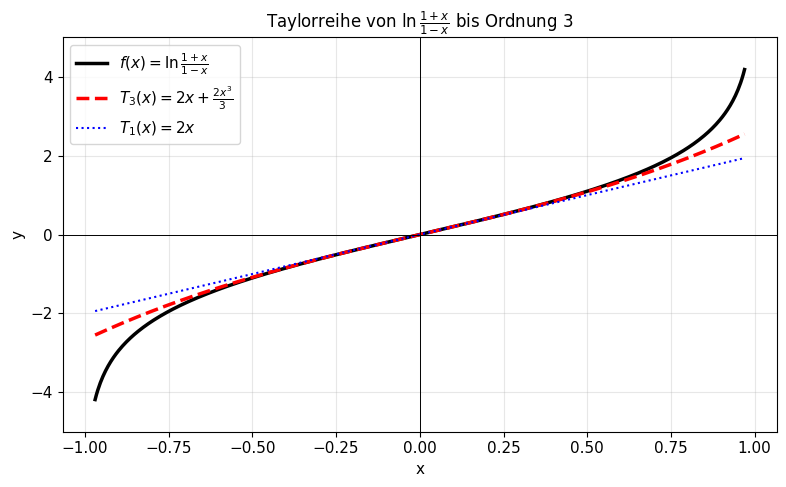

In [70]:
x_num = np.linspace(-0.97, 0.97, 500)
f_num = np.log((1 + x_num) / (1 - x_num))
T3_num = 2*x_num + (2/3)*x_num**3
T1_num = 2*x_num

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_num, f_num, 'k-', lw=2.5, label=r'$f(x) = \ln\frac{1+x}{1-x}$')
ax.plot(x_num, T3_num, 'r--', lw=2.5, label=r'$T_3(x) = 2x + \frac{2x^3}{3}$')
ax.plot(x_num, T1_num, 'b:', lw=1.5, label=r'$T_1(x) = 2x$')

ax.set_ylim(-5, 5)
ax.axhline(0, color='k', lw=0.7)
ax.axvline(0, color='k', lw=0.7)
ax.grid(True, alpha=0.3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(r'Taylorreihe von $\ln\frac{1+x}{1-x}$ bis Ordnung 3')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
### Aufgabe 6

Entwickeln Sie die Funktion $f(x) = \arctan\dfrac{x}{1+x}$ in eine Taylorreihe um den Nullpunkt bis zum Glied 3. Ordnung.

Plotten Sie die Funktion und die Taylorreihe.

#### Methode: Direkte Ableitung

Sei $g(x) = \dfrac{x}{1+x}$. Dann ist $f(x) = \arctan(g(x))$.

#### Schritt 1: Erste Ableitung (Kettenregel)

$$f'(x) = \frac{1}{1+g(x)^2} \cdot g'(x)$$

Mit $g'(x) = \dfrac{(1+x) - x}{(1+x)^2} = \dfrac{1}{(1+x)^2}$ und $g(0) = 0$:

$$f'(0) = \frac{1}{1+0} \cdot \frac{1}{1} = 1$$

#### Schritt 2: Werte berechnen

- $f(0) = \arctan(0) = 0$

- $f'(0) = 1$ (wie oben)

Für die höheren Ableitungen nutzen wir **SymPy** (die Ausdrücke werden rasch komplex):

- $f''(0)$: Aus Symmetrieüberlegungen oder Rechnung: $f''(0) = -2$

- $f'''(0) = 6$

#### Schritt 3: Taylorformel

$$T_3(x) = 0 + 1\cdot x + \frac{-2}{2!}x^2 + \frac{6}{3!}x^3$$

$$\boxed{T_3(x) = x - x^2 + x^3}$$

In [71]:
f6 = atan(x / (1 + x))

# Ableitungen bei x=0
for k in range(4):
    dk = diff(f6, x, k).subs(x, 0)
    coeff = Rational(dk, factorial(k)) if dk != 0 else 0
    print(f"f^({k})(0) = {dk}   ->  Koeffizient x^{k}: {coeff}")

# SymPy-Verifikation
t6_s = series(f6, x, 0, 4)
print("\nTaylorreihe [SymPy]:", t6_s)

# Alternativweg: Geometrische Reihe + arctan-Reihe
u = x / (1 + x)
u_series = series(u, x, 0, 4)
print("\nu = x/(1+x) als Reihe:", u_series)

f^(0)(0) = 0   ->  Koeffizient x^0: 0
f^(1)(0) = 1   ->  Koeffizient x^1: 1
f^(2)(0) = -2   ->  Koeffizient x^2: -1
f^(3)(0) = 4   ->  Koeffizient x^3: 2/3

Taylorreihe [SymPy]: x - x**2 + 2*x**3/3 + O(x**4)

u = x/(1+x) als Reihe: x - x**2 + x**3 + O(x**4)


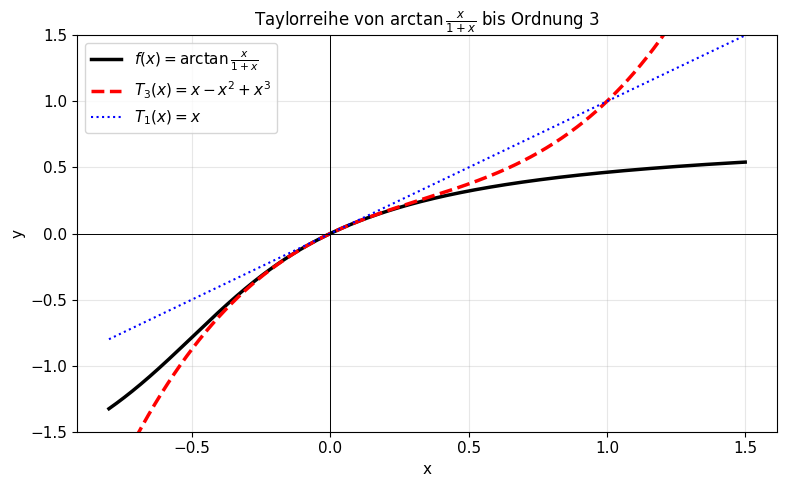

In [72]:
x_num = np.linspace(-0.8, 1.5, 500)
# Vorsicht: f ist für x = -1 nicht definiert
mask = x_num > -0.999
f_num = np.arctan(x_num[mask] / (1 + x_num[mask]))
T3_num_all = x_num - x_num**2 + x_num**3

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_num[mask], f_num, 'k-', lw=2.5, label=r'$f(x) = \arctan\frac{x}{1+x}$')
ax.plot(x_num, T3_num_all, 'r--', lw=2.5, label=r'$T_3(x) = x - x^2 + x^3$')
ax.plot(x_num, x_num, 'b:', lw=1.5, label=r'$T_1(x) = x$')

ax.set_ylim(-1.5, 1.5)
ax.axhline(0, color='k', lw=0.7)
ax.axvline(0, color='k', lw=0.7)
ax.grid(True, alpha=0.3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(r'Taylorreihe von $\arctan\frac{x}{1+x}$ bis Ordnung 3')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
### Aufgabe 7

Entwickeln Sie die Funktion $f(x) = e^{\sin(x)}$ in eine Taylorreihe um den Nullpunkt bis zum Glied 4. Ordnung.

Plotten Sie die Funktion und die Taylorreihe.

#### Methode: Verkettung der Reihen

Wir nutzen $\sin x = x - \dfrac{x^3}{6} + O(x^5)$ und $e^u = 1 + u + \dfrac{u^2}{2} + \dfrac{u^3}{6} + \dfrac{u^4}{24} + \cdots$

Setze $u = \sin x$:

$$u = x - \frac{x^3}{6} + \cdots$$

$$u^2 = \left(x - \frac{x^3}{6}\right)^2 = x^2 - \frac{x^4}{3} + O(x^6)$$

$$u^3 = x^3 + O(x^5), \qquad u^4 = x^4 + O(x^6)$$

Jetzt einsetzen:
$$e^{\sin x} = 1 + u + \frac{u^2}{2} + \frac{u^3}{6} + \frac{u^4}{24} + \cdots$$

$$= 1 + \left(x - \frac{x^3}{6}\right) + \frac{1}{2}\left(x^2 - \frac{x^4}{3}\right) + \frac{x^3}{6} + \frac{x^4}{24} + O(x^5)$$

Terme nach Potenzen sortieren:

| Potenz | Beitrag |
|--------|---------|
| $x^0$ | $1$ |
| $x^1$ | $x$ |
| $x^2$ | $\dfrac{x^2}{2}$ |
| $x^3$ | $-\dfrac{x^3}{6} + \dfrac{x^3}{6} = 0$ |
| $x^4$ | $-\dfrac{x^4}{6} + \dfrac{x^4}{24} = -\dfrac{4x^4}{24} + \dfrac{x^4}{24} = -\dfrac{3x^4}{24} = -\dfrac{x^4}{8}$ |

$$\boxed{T_4(x) = 1 + x + \frac{x^2}{2} - \frac{x^4}{8}}$$

In [73]:
f7 = exp(sin(x))

# Ableitungen bei x=0
for k in range(5):
    dk = diff(f7, x, k).subs(x, 0)
    coeff = Rational(dk, factorial(k)) if dk != 0 else 0
    print(f"f^({k})(0) = {dk}   ->  Koeffizient x^{k}: {coeff}")

# SymPy-Verifikation
t7_s = series(f7, x, 0, 5)
print("\nTaylorreihe [SymPy]:", t7_s)

f^(0)(0) = 1   ->  Koeffizient x^0: 1
f^(1)(0) = 1   ->  Koeffizient x^1: 1
f^(2)(0) = 1   ->  Koeffizient x^2: 1/2
f^(3)(0) = 0   ->  Koeffizient x^3: 0
f^(4)(0) = -3   ->  Koeffizient x^4: -1/8

Taylorreihe [SymPy]: 1 + x + x**2/2 - x**4/8 + O(x**5)


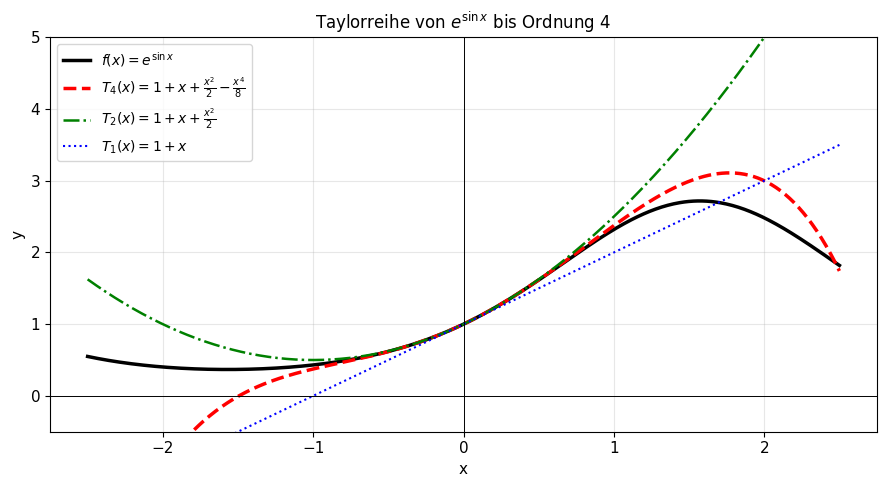

In [74]:
x_num = np.linspace(-2.5, 2.5, 500)
f_num = np.exp(np.sin(x_num))
T4_num = 1 + x_num + x_num**2/2 - x_num**4/8
T2_num = 1 + x_num + x_num**2/2
T1_num = 1 + x_num

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_num, f_num, 'k-', lw=2.5, label=r'$f(x) = e^{\sin x}$')
ax.plot(x_num, T4_num, 'r--', lw=2.5, label=r'$T_4(x) = 1 + x + \frac{x^2}{2} - \frac{x^4}{8}$')
ax.plot(x_num, T2_num, 'g-.', lw=1.8, label=r'$T_2(x) = 1 + x + \frac{x^2}{2}$')
ax.plot(x_num, T1_num, 'b:',  lw=1.5, label=r'$T_1(x) = 1 + x$')

ax.set_ylim(-0.5, 5)
ax.axhline(0, color='k', lw=0.7)
ax.axvline(0, color='k', lw=0.7)
ax.grid(True, alpha=0.3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(r'Taylorreihe von $e^{\sin x}$ bis Ordnung 4')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
### Aufgabe 8

Entwickeln Sie die Funktion $f(x) = \dfrac{1 - \cos x}{\ln(x+1)}$ in eine Taylorreihe um den Nullpunkt bis zum Glied 1. Ordnung.

Plotten Sie die Funktion und die Taylorreihe.

#### Hinweis: Unbestimmte Form bei $x = 0$

Für $x \to 0$ gilt sowohl $1 - \cos x \to 0$ als auch $\ln(x+1) \to 0$, also liegt eine **$\tfrac{0}{0}$-Form** vor. Wir müssen die Funktion über ihre Taylorreihe analysieren.

#### Schritt 1: Zähler entwickeln

$$1 - \cos x = \frac{x^2}{2} - \frac{x^4}{24} + \cdots$$

#### Schritt 2: Nenner entwickeln

$$\ln(1 + x) = x - \frac{x^2}{2} + \frac{x^3}{3} - \cdots$$

#### Schritt 3: Division der Reihen

$$f(x) = \frac{\frac{x^2}{2} - \frac{x^4}{24} + \cdots}{x - \frac{x^2}{2} + \frac{x^3}{3} - \cdots}$$

$x$ aus Zähler und Nenner ausklammern:

$$f(x) = \frac{x\left(\frac{x}{2} - \frac{x^3}{24} + \cdots\right)}{x\left(1 - \frac{x}{2} + \frac{x^2}{3} - \cdots\right)} = \frac{\frac{x}{2} + O(x^3)}{1 - \frac{x}{2} + O(x^2)}$$

Mit $\dfrac{1}{1-u} \approx 1 + u$ für kleine $u = \dfrac{x}{2}$:

$$f(x) \approx \frac{x}{2} \cdot \left(1 + \frac{x}{2} + \cdots\right) = \frac{x}{2} + \frac{x^2}{4} + \cdots$$

#### Ergebnis bis Ordnung 1

Da $f(0)$ nicht direkt ausgewertet werden kann (Grenzwert), gilt:

$$\lim_{x \to 0} f(x) = \lim_{x \to 0} \frac{x/2 + O(x^2)}{1 + O(x)} = 0$$

und $f'(0)$ ergibt sich aus dem Koeffizient vor $x$:

$$\boxed{T_1(x) = \frac{x}{2}}$$

> **Interpretation:** Der Grenzwert $\lim_{x \to 0} f(x) = 0$ existiert, obwohl Zähler und Nenner einzeln gegen 0 gehen. Die Funktion kann stetig auf $x = 0$ erweitert werden mit $f(0) := 0$.

In [75]:
f8 = (1 - cos(x)) / log(x + 1)

# Grenzwert bei x=0 (da f dort nicht definiert)
lim_f8 = limit(f8, x, 0)
print("lim_{x->0} f(x) =", lim_f8)

# Taylorreihe (SymPy arbeitet mit erweiterter Funktion)
t8_s = series(f8, x, 0, 2)  # bis O(x^2), also Terme bis x^1
print("Taylorreihe [SymPy]:", t8_s)

# Zähler und Nenner separat
print("\nZähler  1-cos(x):", series(1 - cos(x), x, 0, 4))
print("Nenner  ln(1+x) :", series(log(1+x), x, 0, 4))

lim_{x->0} f(x) = 0
Taylorreihe [SymPy]: x/2 + O(x**2)

Zähler  1-cos(x): x**2/2 + O(x**4)
Nenner  ln(1+x) : x - x**2/2 + x**3/3 + O(x**4)


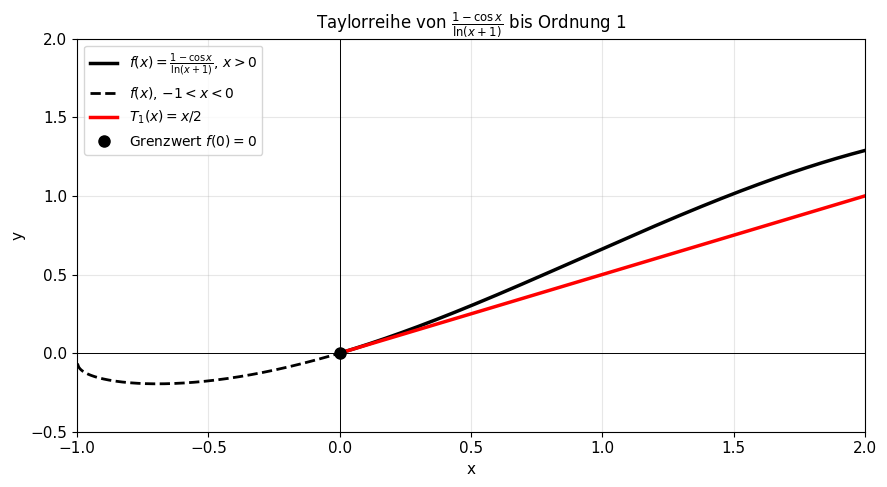

In [76]:
x_num = np.linspace(0.001, 2.0, 500)  # x > 0 (Definitionsbereich)
f_num = (1 - np.cos(x_num)) / np.log(x_num + 1)
T1_num = x_num / 2

# Auch links von 0 plotten (-1 < x < 0)
x_neg = np.linspace(-0.999, -0.001, 200)
f_neg = (1 - np.cos(x_neg)) / np.log(x_neg + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_num, f_num, 'k-', lw=2.5, label=r'$f(x) = \frac{1-\cos x}{\ln(x+1)}$, $x > 0$')
ax.plot(x_neg, f_neg, 'k--', lw=2, label=r'$f(x)$, $-1 < x < 0$')
ax.plot(x_num, T1_num, 'r-', lw=2.5, label=r'$T_1(x) = x/2$')
ax.plot(0, 0, 'ko', ms=8, zorder=5, label=r'Grenzwert $f(0) = 0$')

ax.set_ylim(-0.5, 2)
ax.set_xlim(-1, 2)
ax.axhline(0, color='k', lw=0.7)
ax.axvline(0, color='k', lw=0.7)
ax.grid(True, alpha=0.3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(r'Taylorreihe von $\frac{1-\cos x}{\ln(x+1)}$ bis Ordnung 1')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()